In [1]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [2]:
import numpy as np


In [3]:
np.column_stack(([1,2,3],[4,5,6]))

array([[1, 4],
       [2, 5],
       [3, 6]])

In [4]:
fish_data=np.column_stack((fish_length,fish_weight))
fish_data[:5]

array([[ 25.4, 242. ],
       [ 26.3, 290. ],
       [ 26.5, 340. ],
       [ 29. , 363. ],
       [ 29. , 430. ]])

In [5]:
fish_data.shape

(49, 2)

In [6]:
(np.ones(35),np.zeros(14))

(array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [7]:
fish_target=np.concatenate((np.ones(35),np.zeros(14)))

In [8]:
# 사이킷런으로 훈련 세트와 테스트 세트로 나누기
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target =train_test_split( fish_data,fish_target, random_state=42)

In [20]:
#훈련데이터, 테스트데이터, 훈련정답데이터, 테스트정답데이터
train_input.shape, test_input.shape, train_target.shape, test_target.shape

((36, 2), (13, 2), (36,), (13,))

In [9]:
train_input

array([[  30. ,  450. ],
       [  29. ,  363. ],
       [  29.7,  500. ],
       [  11.3,    8.7],
       [  11.8,   10. ],
       [  13. ,   12.2],
       [  32. ,  600. ],
       [  30.7,  500. ],
       [  33. ,  700. ],
       [  35. ,  700. ],
       [  41. ,  975. ],
       [  38.5,  920. ],
       [  25.4,  242. ],
       [  12. ,    9.8],
       [  39.5,  925. ],
       [  29.7,  450. ],
       [  37. , 1000. ],
       [  31. ,  500. ],
       [  10.5,    7.5],
       [  26.3,  290. ],
       [  34. ,  685. ],
       [  26.5,  340. ],
       [  10.6,    7. ],
       [   9.8,    6.7],
       [  35. ,  680. ],
       [  11.2,    9.8],
       [  31. ,  475. ],
       [  34.5,  620. ],
       [  33.5,  610. ],
       [  15. ,   19.9],
       [  34. ,  575. ],
       [  30. ,  390. ],
       [  11.8,    9.9],
       [  32. ,  600. ],
       [  36. ,  850. ],
       [  11. ,    9.7]])

In [10]:
test_target

array([1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [11]:
train_input, test_input, train_target, test_target =train_test_split( 
    fish_data,
    fish_target,
    stratify=fish_target,
    random_state=42)

In [12]:
test_target

array([0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

#  2. 거리 기반 모델의 문제

In [13]:
from sklearn.neighbors import KNeighborsClassifier

kn=KNeighborsClassifier()
kn.fit(train_input,train_target)
kn.score(test_input,test_target)

1.0

In [14]:
print(kn.predict([[25,150]]))

[0.]


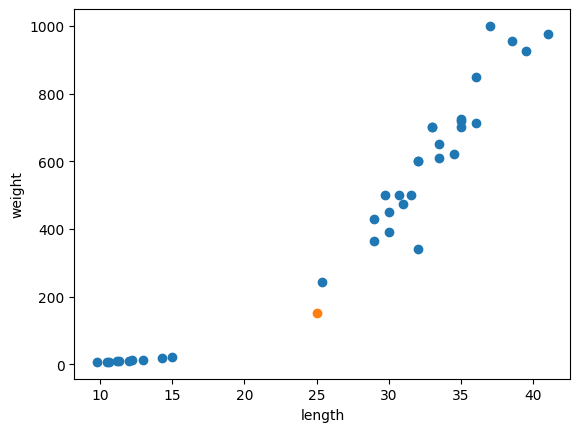

In [15]:
import matplotlib.pylab as plt
plt.scatter(train_input[:,0],train_input[:,1])
plt.scatter(25,150)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [16]:
#25,150의 물고기 이웃 k 값 5개 알려줘
distance,indexes=kn.kneighbors([[25,150]])
distance, indexes

(array([[ 92.00086956, 130.48375378, 130.73859415, 138.32150953,
         138.39320793]]),
 array([[21, 33, 19, 30,  1]]))

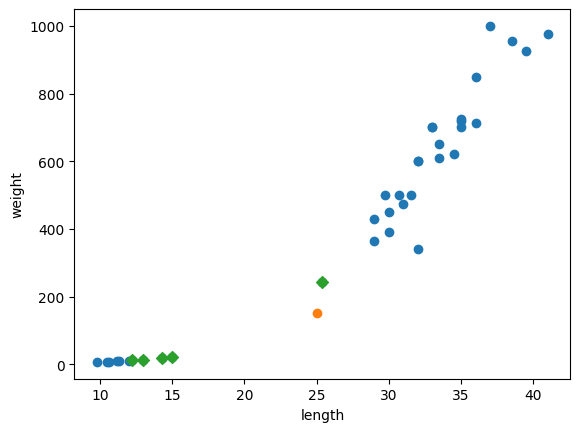

In [17]:
import matplotlib.pylab as plt
plt.scatter(train_input[:,0],train_input[:,1])
plt.scatter(25,150)
plt.scatter(train_input[indexes,0],train_input[indexes,1],marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [18]:
#가까운 이웃인 5개의 샘플, 이중에 도미는 하나
print(train_input[indexes])

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 14.3  19.7]
  [ 13.   12.2]
  [ 12.2  12.2]]]


In [19]:
print(train_target[indexes])

[[1. 0. 0. 0. 0.]]


# 3.해결방법:특정 스케일 맞추기
- 이과정을 데이터 전처리라고 한다.

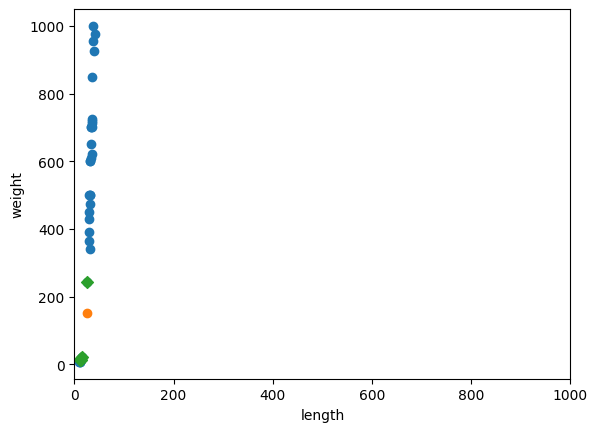

In [20]:
import matplotlib.pylab as plt
plt.scatter(train_input[:,0],train_input[:,1])
plt.scatter(25,150)
plt.scatter(train_input[indexes,0],train_input[indexes,1],marker='D')
plt.xlim((0,1000))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

# 4.표준화
- (값-평균)/표준편차

In [21]:
#각열의 평균
mean=np.mean(train_input,axis=0)
#각열의 표준편차
std=np.std(train_input,axis=0)
mean,std

(array([ 27.29722222, 454.09722222]), array([  9.98244253, 323.29893931]))

In [22]:
train_scaled=(train_input-mean)/std
#평균이0, 표준편차1인 표준화로 변경
train_scaled

array([[ 0.24070039,  0.14198246],
       [-1.51237757, -1.36683783],
       [ 0.5712808 ,  0.76060496],
       [-1.60253587, -1.37766373],
       [ 1.22242404,  1.45655528],
       [ 0.17057727, -0.07453542],
       [ 0.87180845,  0.80390854],
       [ 0.87180845,  1.22457184],
       [ 0.37092904,  0.06465464],
       [ 0.77163257,  0.82246721],
       [ 0.97198434,  1.68853872],
       [-1.61255346, -1.3742613 ],
       [ 0.72154463,  0.51315596],
       [-1.53241275, -1.3742613 ],
       [ 0.17057727, -0.28177396],
       [ 0.5712808 ,  0.76060496],
       [ 0.34087627,  0.14198246],
       [ 1.12224816,  1.54934866],
       [ 0.62136874,  0.60594934],
       [-1.30200822, -1.34363949],
       [ 0.42101698,  0.14198246],
       [-0.19005591, -0.65604058],
       [-1.75279969, -1.38384995],
       [ 0.47110492,  0.45129371],
       [-1.68267658, -1.38137546],
       [ 0.62136874,  0.48222484],
       [-1.67265899, -1.38292202],
       [ 0.77163257,  0.76060496],
       [ 0.47110492,

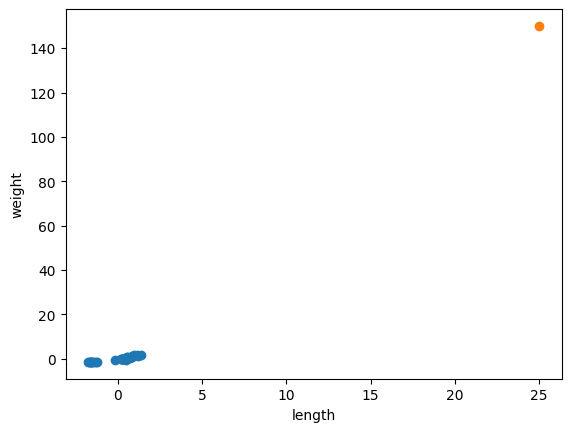

In [23]:
#셈플도 동일한 기준으로 변환해야 한다. 
import matplotlib.pylab as plt
plt.scatter(train_scaled[:,0],train_scaled[:,1])
plt.scatter(25,150)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()


In [24]:
#셈플다시 계산
new=([25,150]-mean)/std
new

array([-0.23012627, -0.94060693])

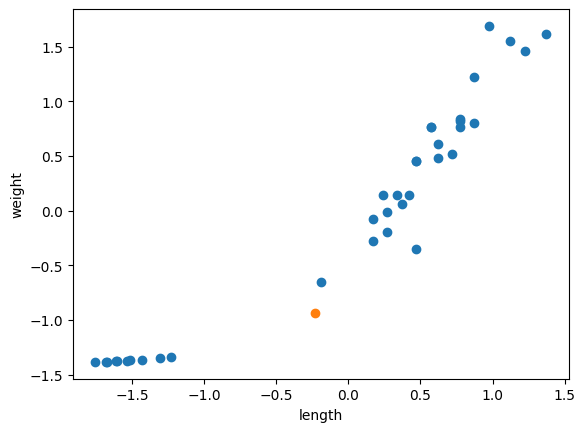

In [25]:
#셈플도 동일한 기준으로 변환해야 한다. 
import matplotlib.pylab as plt
plt.scatter(train_scaled[:,0],train_scaled[:,1])
plt.scatter(new[0],new[1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [26]:
kn.fit(train_scaled,train_target)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [27]:
test_scaled=(test_input-mean)/std


In [28]:
kn.score(test_scaled,test_target)

1.0

In [29]:
kn.predict([new])

array([1.])

In [30]:
distance,indexes=kn.kneighbors([new])
distance, indexes

(array([[0.2873737 , 0.7711188 , 0.89552179, 0.91493515, 0.95427626]]),
 array([[21, 14, 34, 32,  5]]))

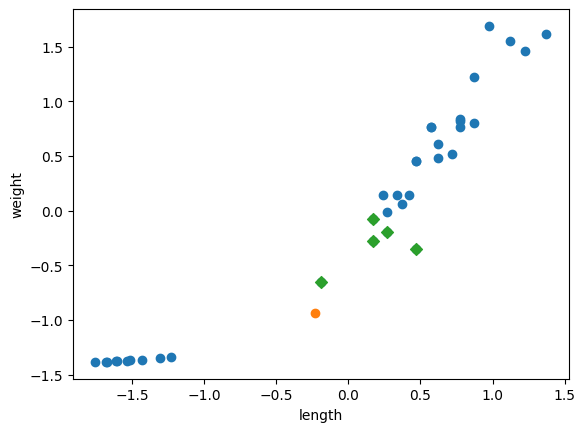

In [31]:
import matplotlib.pylab as plt
plt.scatter(train_scaled[:,0],train_scaled[:,1])

plt.scatter(new[0],new[1])
plt.scatter(train_scaled[indexes,0],train_scaled[indexes,1],marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()



# 9.sklearn으로 쉽게 나누기

In [37]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(train_input)
#scaler fit은 데이터와 답을 주는 kn과 다름. 데이터의 통계값(평균,표준편차)를 기억한다., 여기에서의 fit은 공부하는것이 아니라 계산을 한다.
train_scaled=scaler.transform(train_input)
#위에서 평균과 표준편차를 기억했다가 transform을 거쳐야 계산된 값이 나온다. (값-평균)/표준편차

test_scaled=scaler.transform(test_input)

kn.fit(train_scaled,train_target)#데이터와 정답을 관계를 학습
print(kn.score(test_scaled,test_target))


1.0


In [38]:
scaler.transform(train_input)

array([[ 0.24070039,  0.14198246],
       [-1.51237757, -1.36683783],
       [ 0.5712808 ,  0.76060496],
       [-1.60253587, -1.37766373],
       [ 1.22242404,  1.45655528],
       [ 0.17057727, -0.07453542],
       [ 0.87180845,  0.80390854],
       [ 0.87180845,  1.22457184],
       [ 0.37092904,  0.06465464],
       [ 0.77163257,  0.82246721],
       [ 0.97198434,  1.68853872],
       [-1.61255346, -1.3742613 ],
       [ 0.72154463,  0.51315596],
       [-1.53241275, -1.3742613 ],
       [ 0.17057727, -0.28177396],
       [ 0.5712808 ,  0.76060496],
       [ 0.34087627,  0.14198246],
       [ 1.12224816,  1.54934866],
       [ 0.62136874,  0.60594934],
       [-1.30200822, -1.34363949],
       [ 0.42101698,  0.14198246],
       [-0.19005591, -0.65604058],
       [-1.75279969, -1.38384995],
       [ 0.47110492,  0.45129371],
       [-1.68267658, -1.38137546],
       [ 0.62136874,  0.48222484],
       [-1.67265899, -1.38292202],
       [ 0.77163257,  0.76060496],
       [ 0.47110492,

###  11. 연습 문제
- StandardScaler 대신 MinMaxScaler 사용해보기

In [44]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

scaler=MinMaxScaler()
scaler.fit(train_input)

train_scaled=scaler.transform(train_input)
test_scaled=scaler.transform(test_input)

kn=KNeighborsClassifier()
kn.fit(train_scaled,train_target)
print(kn.score(test_scaled,test_target))

1.0


## 문제2
- 스케일링 전후 정확도 비교하기

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [54]:
# 스케일링 전(원본)
kn=KNeighborsClassifier()
kn.fit(train_input,train_target)
score_before=kn.score(test_input,test_target)

# 스케일링 후
scaler=StandardScaler()
scaler.fit(train_input)
train_scaled=scaler.transform(train_input)
test_scaled=scaler.transform(test_input)

kn=KNeighborsClassifier()
kn.fit(train_scaled,train_target)
score_after=kn.score(test_scaled,test_target)

score_before, score_after


(1.0, 1.0)

In [81]:
#값이 모두 1.0정확하게 나옴
#그럼 왜 스케일링한거지?
#지금 데이터셋이 너무 하하기 때문이다. 너무 구분이 잘 된 데이터셍이기 때문
#현실데이터라면 이렇ㅈ 않다
#스케일링은 보험같은 존재
#그래서 일부러 무게를 100배 키워보자
train_input[:,1]=train_input[:,1]*100

In [67]:
# 스케일링 전(원본)
kn=KNeighborsClassifier()
kn.fit(train_input,train_target)
score_before=kn.score(test_input,test_target)

# 스케일링 후
scaler=StandardScaler()
scaler.fit(train_input)
train_scaled=scaler.transform(train_input)
test_scaled=scaler.transform(test_input)

kn=KNeighborsClassifier()
kn.fit(train_scaled,train_target)
score_after=kn.score(test_scaled,test_target)

score_before, score_after

(0.3076923076923077, 1.0)

In [91]:
train_input[:,1]=train_input[:,1]/100

### 문제 3

K 값을 3, 5, 7로 바꿔보시오.

In [92]:
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
kn.score(test_scaled,test_target)

1.0

In [93]:
kn=KNeighborsClassifier(n_neighbors=7)
kn.fit(train_scaled,train_target)
kn.score(test_input,test_target)

0.6923076923076923

In [94]:
kn=KNeighborsClassifier(n_neighbors=5)
kn.fit(train_scaled,train_target)
kn.score(test_scaled,test_target)

1.0

In [96]:
scaler=StandardScaler()
scaler.fit(train_input)
train_scaled=scaler.transform(train_input)
test_scaled=scaler.transform(test_input)

for k in[3,4,5,15,20]:
    kn=KNeighborsClassifier(n_neighbors=k)
    kn.fit(train_scaled,train_target)
    score=kn.score(test_scaled,test_target)
    print(f"k={k} 정확도:{score}")

k=3 정확도:1.0
k=4 정확도:1.0
k=5 정확도:1.0
k=15 정확도:0.9230769230769231
k=20 정확도:0.8461538461538461


In [ ]:
#k가 작으면(1~3)민감해서 과적합 쪽으로 갈 수 있고
#K가 커지면(7이상)둔감해저서 과소적합 쪽으로 갈 수 있음
#그래서 k는 보통 여러 값 테스트해서 고릅니다.